#A/B Testing — GastroCare

**Tujuan:** Membandingkan dua versi model MLP untuk klasifikasi penyakit lambung.

| | Model A | Model B |
|---|---|---|
| **Nama** | Baseline MLP | Deep MLP |
| **Arsitektur** | 2 hidden layer (64, 32) | 3 hidden layer (128, 64, 32) |
| **Dropout** | 0.3 | 0.4 |
| **Optimizer** | Adam (lr=0.001) | Adam (lr=0.0005) |

**Metrik yang dibandingkan:** Accuracy, Precision, Recall, F1-Score

## Install & Import

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version : {tf.__version__}")
print("Import berhasil")

TensorFlow version : 2.20.0
Import berhasil


##Load Dataset

In [11]:
# ─── Konstanta fitur ──────────────────────────────────────────
FITUR_ORDINAL = ['nyeri_ulu_hati']
FITUR_BINER   = [
    'mual', 'muntah', 'kembung', 'heartburn', 'asam_naik_tenggorokan',
    'diare', 'demam', 'penurunan_berat_badan', 'cepat_kenyang',
    'muntah_tak_tercerna', 'nyeri_perut_kosong', 'feses_hitam',
    'riwayat_nsaid', 'stres_tinggi', 'batuk_kronis', 'suara_serak',
    'anemia_lemas', 'nafsu_makan_hilang', 'nyeri_dada'
]
FITUR_SEMUA = FITUR_ORDINAL + FITUR_BINER
LABEL       = 'label'
CLASSES     = [
    'Sehat', 'Gastritis', 'Tukak_Lambung', 'GERD',
    'Dispepsia_Fungsional', 'Gastroparesis', 'Gastroenteritis', 'Kanker_Lambung'
]
N_CLASSES = len(CLASSES)


# Load data
df = pd.read_csv('dataset_lambung_dirty.csv')
df = df.drop_duplicates()
for col in FITUR_BINER:
 df.loc[~df[col].isin([0,1,2,3]), col] = np.nan
for col in FITUR_SEMUA:
 df[col] = df[col].fillna(df[col].median())

print(f"Dataset shape : {df.shape}")
print(f"\nDistribusi kelas:")
print(df[LABEL].value_counts().to_string())

Dataset shape : (3275, 21)

Distribusi kelas:
label
Gastritis               419
Tukak_Lambung           418
Sehat                   415
Dispepsia_Fungsional    412
GERD                    412
Kanker_Lambung          409
Gastroparesis           401
Gastroenteritis         389


##Preprocessing & Split Data

In [12]:
# Label Encoding
le = LabelEncoder()
y_encoded = le.fit_transform(df[LABEL])

X = df[FITUR_SEMUA].values
y = y_encoded

# Split 70% train / 15% val / 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f"Train : {X_train.shape[0]} sampel")
print(f"Val   : {X_val.shape[0]} sampel")
print(f"Test  : {X_test.shape[0]} sampel")

Train : 2292 sampel
Val   : 491 sampel
Test  : 492 sampel


##Definisi Model A dan Model B

- **Model A (Baseline):** lebih sederhana, 2 hidden layer
- **Model B (Deep):** lebih dalam, 3 hidden layer + dropout lebih besar

In [13]:
def build_model_A(input_dim, n_classes):
    """Model A — Baseline MLP: 2 hidden layer (64, 32)"""
    inp = layers.Input(shape=(input_dim,))
    x   = layers.Dense(64, activation='relu')(inp)
    x   = layers.Dropout(0.3)(x)
    x   = layers.Dense(32, activation='relu')(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)

    model = Model(inp, out, name='Model_A_Baseline')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def build_model_B(input_dim, n_classes):
    """Model B — Deep MLP: 3 hidden layer (128, 64, 32) + dropout lebih besar"""
    inp = layers.Input(shape=(input_dim,))
    x   = layers.Dense(128, activation='relu')(inp)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dropout(0.4)(x)
    x   = layers.Dense(64, activation='relu')(x)
    x   = layers.Dropout(0.4)(x)
    x   = layers.Dense(32, activation='relu')(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)

    model = Model(inp, out, name='Model_B_Deep')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


INPUT_DIM = X_train.shape[1]

model_A = build_model_A(INPUT_DIM, N_CLASSES)
model_B = build_model_B(INPUT_DIM, N_CLASSES)

model_A.summary()
print()
model_B.summary()

Model: "Model_A_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,688 (14.41 KB)

 Trainable params: 3,688 (14.41 KB)

 Non-trainable params: 0 (0.00 B)

Model: "Model_B_Deep"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,800 (53.91 KB)

 Trainable params: 13,544 (52.91 KB)

 Non-trainable params: 256 (1.00 KB)

##Latih Model A dan Model B

In [14]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=0
)

# Latih Model A
print("=" * 50)
print("🔵 Melatih Model A (Baseline)...")
print("=" * 50)

history_A = model_A.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Latih Model B
print("\n" + "=" * 50)
print("🟢 Melatih Model B (Deep)...")
print("=" * 50)

history_B = model_B.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

print("\n✅ Training selesai!")

🔵 Melatih Model A (Baseline)...
Epoch 1/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3168 - loss: 1.8463 - val_accuracy: 0.6721 - val_loss: 1.4080
Epoch 2/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5593 - loss: 1.3481 - val_accuracy: 0.7800 - val_loss: 0.9169
Epoch 3/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6588 - loss: 1.0148 - val_accuracy: 0.8045 - val_loss: 0.6720
Epoch 4/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7221 - loss: 0.8445 - val_accuracy: 0.8310 - val_loss: 0.5561
Epoch 5/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7430 - loss: 0.7665 - val_accuracy: 0.8432 - val_loss: 0.5023
Epoch 6/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7561 - loss: 0.7137 - val_accuracy: 0.8473 - val_loss: 0.4791
Epoch 7/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7688 - loss: 0.6756 - val_accuracy: 0.8595 - val_loss: 0.4588
Epoch 8/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7775 - loss: 0

##Evaluasi & Bandingkan Hasil

In [15]:
def evaluate_model(model, X_test, y_test, label_encoder):
    """Hitung semua metrik evaluasi untuk satu model."""
    y_pred_proba = model.predict(X_test, verbose=0)
    y_pred       = np.argmax(y_pred_proba, axis=1)

    return {
        'accuracy' : accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted'),
        'recall'   : recall_score(y_test, y_pred, average='weighted'),
        'f1'       : f1_score(y_test, y_pred, average='weighted'),
        'y_pred'   : y_pred
    }

hasil_A = evaluate_model(model_A, X_test, y_test, le)
hasil_B = evaluate_model(model_B, X_test, y_test, le)

# Tabel Perbandingan
metrics = ['accuracy', 'precision', 'recall', 'f1']
df_hasil = pd.DataFrame({
    'Metrik'  : ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Model A (Baseline)': [f"{hasil_A[m]*100:.2f}%" for m in metrics],
    'Model B (Deep)'    : [f"{hasil_B[m]*100:.2f}%" for m in metrics],
    'Selisih'           : [
        f"{(hasil_B[m] - hasil_A[m])*100:+.2f}%" for m in metrics
    ]
})

print("\n" + "=" * 60)
print("📊 HASIL A/B TESTING")
print("=" * 60)
print(df_hasil.to_string(index=False))

# Pemenang
winner = 'Model B (Deep)' if hasil_B['f1'] > hasil_A['f1'] else 'Model A (Baseline)'
selisih = abs(hasil_B['f1'] - hasil_A['f1']) * 100
print(f"\n Pemenang: {winner} (F1 lebih tinggi {selisih:.2f}%)")


📊 HASIL A/B TESTING
   Metrik Model A (Baseline) Model B (Deep) Selisih
 Accuracy             86.99%         52.64% -34.35%
Precision             87.54%         52.18% -35.36%
   Recall             86.99%         52.64% -34.35%
 F1-Score             86.85%         50.47% -36.38%

 Pemenang: Model A (Baseline) (F1 lebih tinggi 36.38%)


##Visualisasi A/B Testing

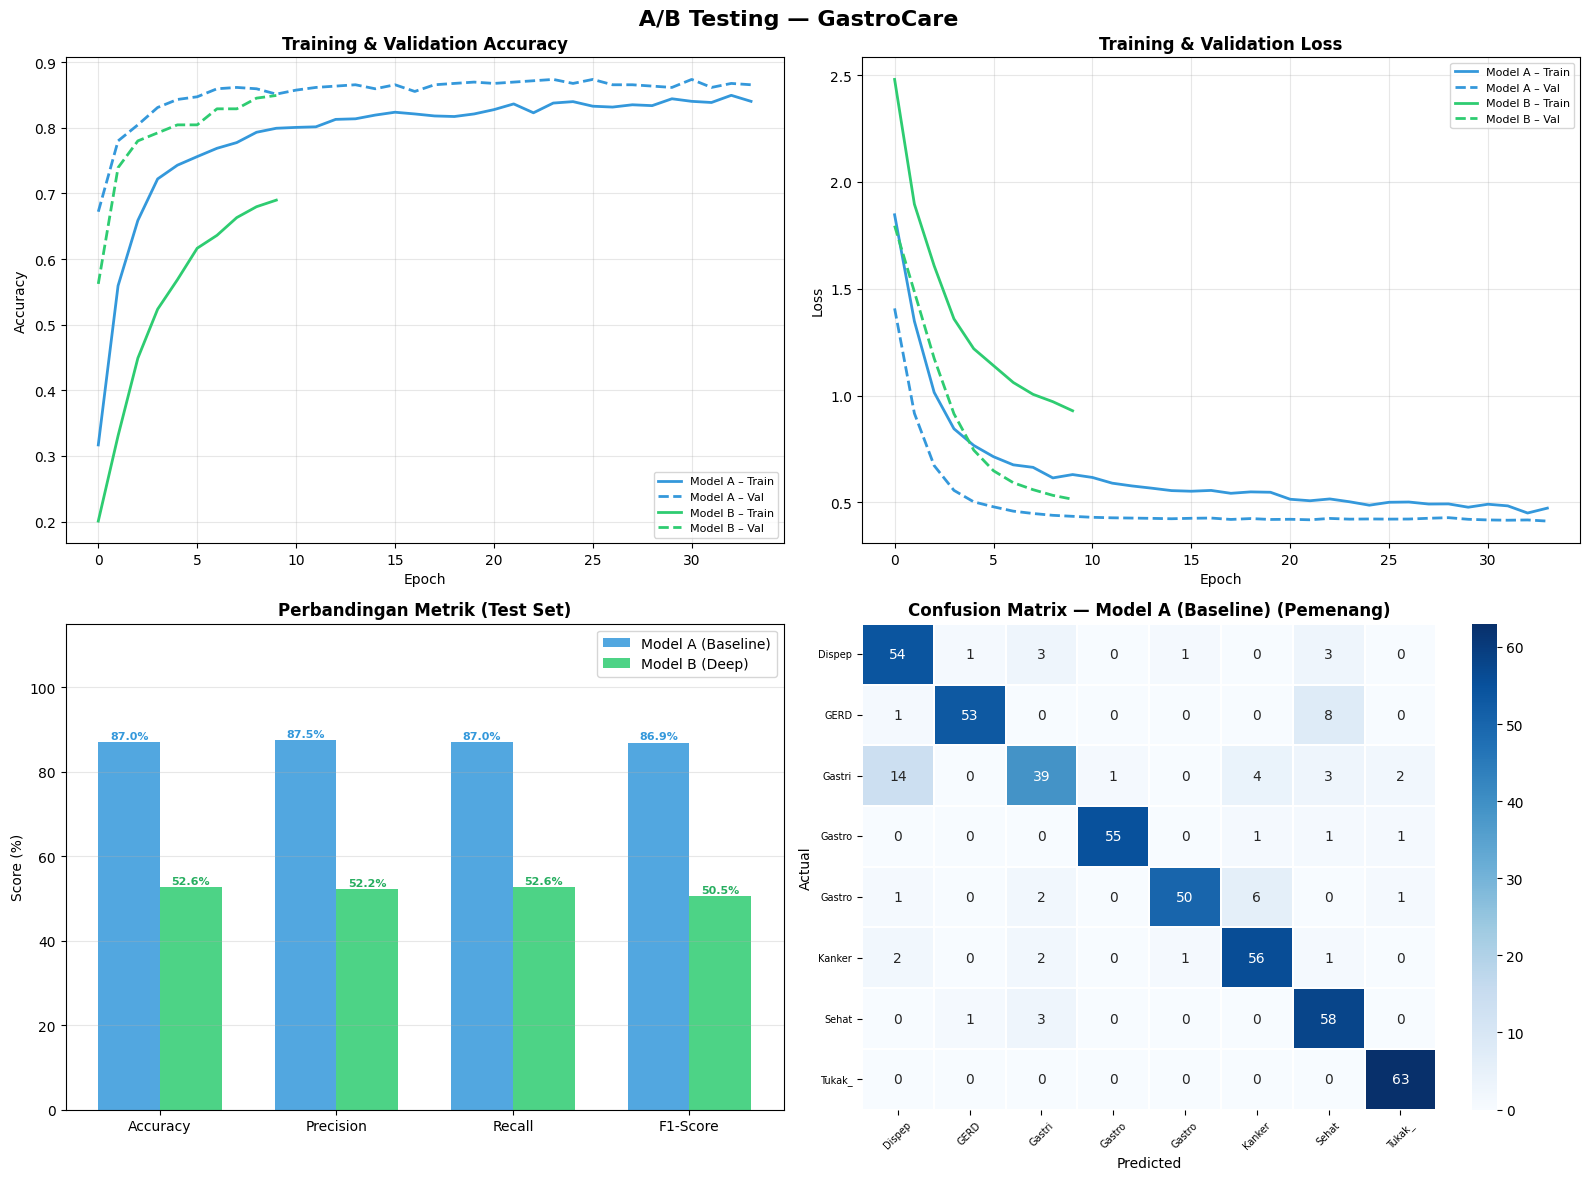


✅ Visualisasi tersimpan sebagai ab_testing_result.png


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(' A/B Testing — GastroCare', fontsize=16, fontweight='bold', y=0.98)

WARNA_A = '#3498DB'  # biru untuk Model A
WARNA_B = '#2ECC71'  # hijau untuk Model B

# Plot 1: Training Accuracy
ax1 = axes[0, 0]
ax1.plot(history_A.history['accuracy'], color=WARNA_A, label='Model A – Train', linewidth=2)
ax1.plot(history_A.history['val_accuracy'], color=WARNA_A, linestyle='--', label='Model A – Val', linewidth=2)
ax1.plot(history_B.history['accuracy'], color=WARNA_B, label='Model B – Train', linewidth=2)
ax1.plot(history_B.history['val_accuracy'], color=WARNA_B, linestyle='--', label='Model B – Val', linewidth=2)
ax1.set_title('Training & Validation Accuracy', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Plot 2: Training Loss
ax2 = axes[0, 1]
ax2.plot(history_A.history['loss'], color=WARNA_A, label='Model A – Train', linewidth=2)
ax2.plot(history_A.history['val_loss'], color=WARNA_A, linestyle='--', label='Model A – Val', linewidth=2)
ax2.plot(history_B.history['loss'], color=WARNA_B, label='Model B – Train', linewidth=2)
ax2.plot(history_B.history['val_loss'], color=WARNA_B, linestyle='--', label='Model B – Val', linewidth=2)
ax2.set_title('Training & Validation Loss', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# Plot 3: Perbandingan Metrik (Bar Chart)
ax3 = axes[1, 0]
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
vals_A = [hasil_A[m] * 100 for m in metrics]
vals_B = [hasil_B[m] * 100 for m in metrics]

x = np.arange(len(metric_names))
width = 0.35
bars_A = ax3.bar(x - width/2, vals_A, width, label='Model A (Baseline)', color=WARNA_A, alpha=0.85)
bars_B = ax3.bar(x + width/2, vals_B, width, label='Model B (Deep)', color=WARNA_B, alpha=0.85)

for bar, v in zip(bars_A, vals_A):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{v:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold', color=WARNA_A)
for bar, v in zip(bars_B, vals_B):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{v:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold', color='#27AE60')

ax3.set_title('Perbandingan Metrik (Test Set)', fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(metric_names)
ax3.set_ylabel('Score (%)')
ax3.set_ylim(0, 115)
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Confusion Matrix Model Pemenang
ax4 = axes[1, 1]
best_model_pred = hasil_B['y_pred'] if hasil_B['f1'] > hasil_A['f1'] else hasil_A['y_pred']
best_name       = 'Model B (Deep)' if hasil_B['f1'] > hasil_A['f1'] else 'Model A (Baseline)'

cm = confusion_matrix(y_test, best_model_pred)
class_names_short = [c[:6] for c in le.classes_]  # potong nama panjang

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=ax4,
    xticklabels=class_names_short,
    yticklabels=class_names_short,
    linewidths=0.3
)
ax4.set_title(f'Confusion Matrix — {best_name} (Pemenang)', fontweight='bold')
ax4.set_xlabel('Predicted')
ax4.set_ylabel('Actual')
ax4.tick_params(axis='x', rotation=45, labelsize=7)
ax4.tick_params(axis='y', rotation=0, labelsize=7)

plt.tight_layout()
plt.savefig('ab_testing_result.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("\n✅ Visualisasi tersimpan sebagai ab_testing_result.png")

##Kesimpulan A/B Testing

In [17]:
print("=" * 60)
print("KESIMPULAN A/B TESTING — GastroCare")
print("=" * 60)
print()

print("Konfigurasi yang Diuji:")
print("  Model A (Baseline) : 2 hidden layer (64→32), dropout=0.3, lr=0.001")
print("  Model B (Deep)     : 3 hidden layer (128→64→32), dropout=0.4, lr=0.0005")
print()

print("Hasil pada Test Set:")
for m, name in zip(metrics, ['Accuracy', 'Precision', 'Recall', 'F1-Score']):
    a, b = hasil_A[m]*100, hasil_B[m]*100
    ikon = '📈' if b > a else '📉' if b < a else '➡️'
    print(f"  {name:<12}: A={a:.2f}%  B={b:.2f}%  {ikon} Selisih {b-a:+.2f}%")

print()
print(f"Rekomendasi: Gunakan {winner}")

if selisih < 1.0:
    print("   ⚠️  Selisih sangat kecil (<1%). Pertimbangkan Model A karena lebih sederhana")
    print("       dan lebih cepat dilatih (Occam's Razor principle).")
else:
    print(f"   ✅ Selisih F1 cukup signifikan ({selisih:.2f}%). Model pemenang layak digunakan.")

KESIMPULAN A/B TESTING — GastroCare

Konfigurasi yang Diuji:
  Model A (Baseline) : 2 hidden layer (64→32), dropout=0.3, lr=0.001
  Model B (Deep)     : 3 hidden layer (128→64→32), dropout=0.4, lr=0.0005

Hasil pada Test Set:
  Accuracy    : A=86.99%  B=52.64%  📉 Selisih -34.35%
  Precision   : A=87.54%  B=52.18%  📉 Selisih -35.36%
  Recall      : A=86.99%  B=52.64%  📉 Selisih -34.35%
  F1-Score    : A=86.85%  B=50.47%  📉 Selisih -36.38%

Rekomendasi: Gunakan Model A (Baseline)
   ✅ Selisih F1 cukup signifikan (36.38%). Model pemenang layak digunakan.
